Features definieren

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import pandas as pd

df = pd.read_pickle("readData.pkl") # Daten laden

# Saubere Feature-Auswahl
feature_cols = [
    "Age",
    "Gender",
    "Country",
    "Device",
    "GameGenre",
    "SessionCount",
    "AverageSessionLength"
]

X = df[feature_cols]
y = df["HighSpender"]   # Zielvariable

numeric_features = ["Age", "SessionCount", "AverageSessionLength"]
categorical_features = ["Gender", "Country", "Device", "GameGenre"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# num für numerisch, cat für kategorisch

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Modelle trainieren

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistische Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    results.append({
        "Modell": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })
    

results_df = pd.DataFrame(results)
display(results_df)

,Modell,Accuracy,Precision,Recall,F1-Score
0,Logistische Regression,0.566942,0.170635,0.447917,0.247126
1,Random Forest,0.841322,0.500000,0.010417,0.020408
2,Gradient Boosting,0.831405,0.000000,0.000000,0.000000


Baseline Modell erstellen

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

baseline = DummyClassifier(strategy="most_frequent")

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", baseline)
])

baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_baseline, zero_division=0))

baseline_results = {
    "Modell": "Baseline",
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline, zero_division=0),
    "Recall": recall_score(y_test, y_pred_baseline, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_baseline, zero_division=0)
}

baseline_results

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       509
           1       0.00      0.00      0.00        96

    accuracy                           0.84       605
   macro avg       0.42      0.50      0.46       605
weighted avg       0.71      0.84      0.77       605



{'Modell': 'Baseline',
 'Accuracy': 0.8413223140495868,
 'Precision': np.float64(0.0),
 'Recall': np.float64(0.0),
 'F1-Score': np.float64(0.0)}

Baseline einfügen

In [7]:
results_df = pd.concat([
    pd.DataFrame([baseline_results]),
    results_df
], ignore_index=True)

results_df

,Modell,Accuracy,Precision,Recall,F1-Score
0,Baseline,0.841322,0.000000,0.000000,0.000000
1,Logistische Regression,0.566942,0.170635,0.447917,0.247126
2,Random Forest,0.841322,0.500000,0.010417,0.020408
3,Gradient Boosting,0.831405,0.000000,0.000000,0.000000


Confusion Matrix

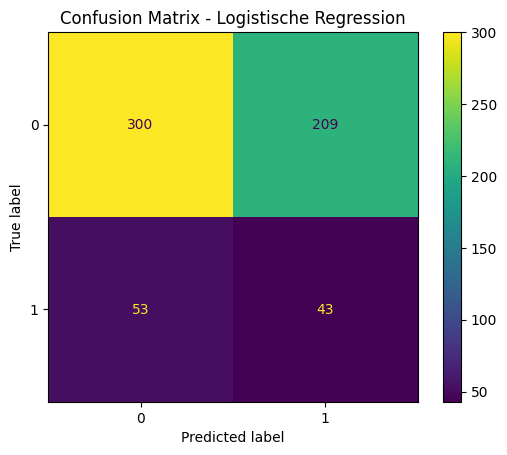

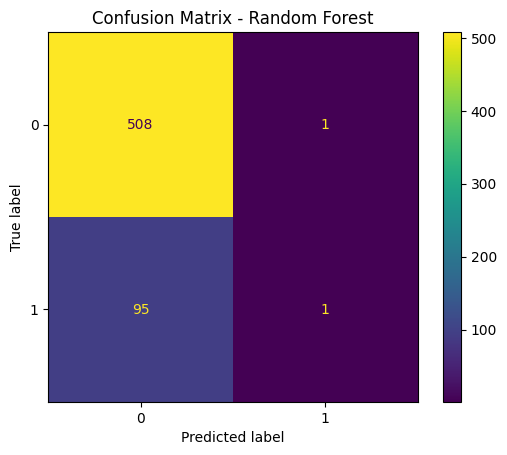

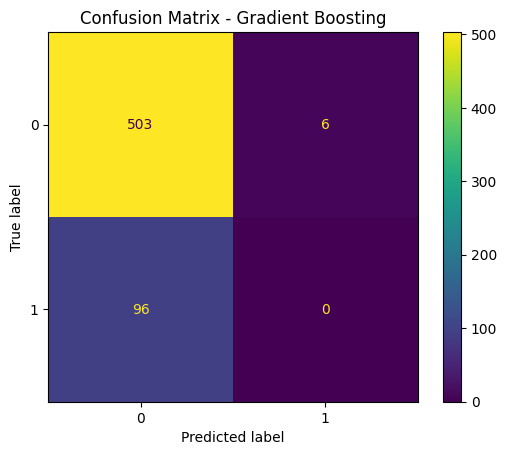

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

Feature Importance

In [ ]:
# Funktion für Feature Namen (macht es schöner zu lesen, wird aktuell nicht verwendet)
def extract_original_feature(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    
    if feature_name.startswith("cat__"):
        clean_name = feature_name.replace("cat__", "")
        
        for original_col in categorical_features:
            if clean_name.startswith(original_col + "_"):
                return original_col
    
    return feature_name

Random Forest (nicht aggregiert)

In [ ]:
# später noch aggregieren (alle Modelle)
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

# Aktuell noch Bugs, wenn Zeit da ist noch fixen und bei den anderen auch hinzufügen
#feature_names = [extract_original_feature(name) for name in feature_names]

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
2,num__AverageSessionLength,0.183421
0,num__Age,0.148886
1,num__SessionCount,0.119151
35,cat__Device_Android,0.020875
36,cat__Device_iOS,0.020236
3,cat__Gender_Female,0.019107
4,cat__Gender_Male,0.018582
17,cat__Country_India,0.015167
50,cat__GameGenre_Simulation,0.014186
42,cat__GameGenre_Casual,0.013336


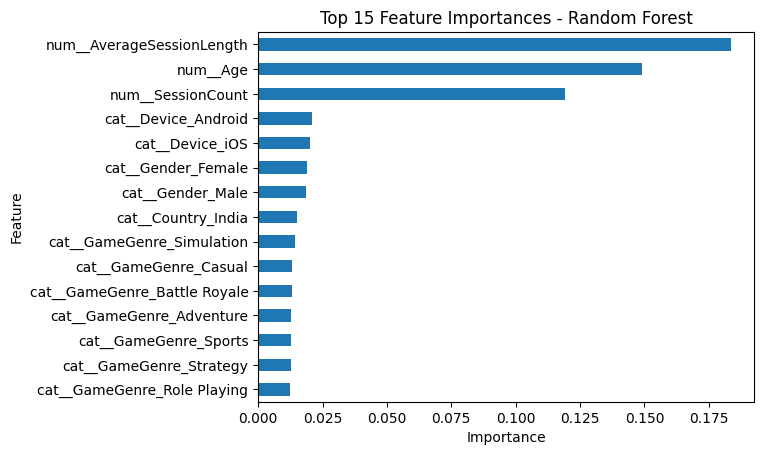

In [22]:
# Diagramm
feature_importance_df.head(15).plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

Random Forest (aggregiert)

In [ ]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df["OriginalFeature"] = feature_importance_df["Feature"].apply(extract_original_feature)

# Importances pro ursprünglicher Variable aufsummieren für Übersicht
aggregated_importance = (
    feature_importance_df
    .groupby("OriginalFeature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

display(aggregated_importance)

,OriginalFeature,Importance
2,Country,0.261491
4,GameGenre,0.193966
1,AverageSessionLength,0.183421
0,Age,0.148886
6,SessionCount,0.119151
3,Device,0.046866
5,Gender,0.046219


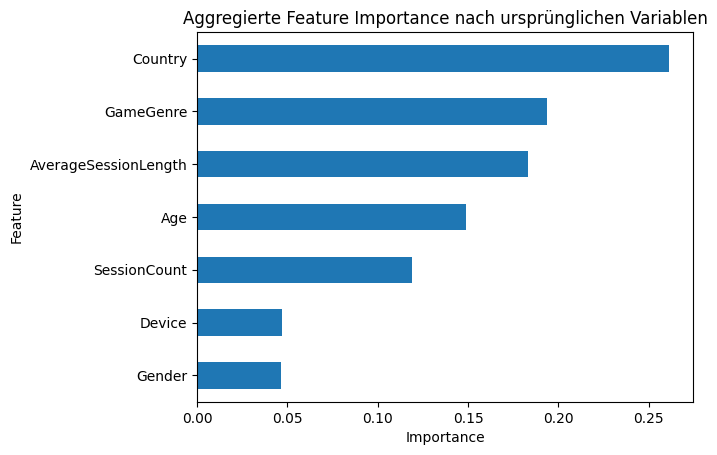

In [13]:
# Diagramm
aggregated_importance.plot(
    kind="barh",
    x="OriginalFeature",
    y="Importance",
    legend=False
)

plt.title("Aggregierte Feature Importance nach ursprünglichen Variablen")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

Gradient Boosting (nicht aggregiert)

In [14]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)

feature_names = gb_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = gb_pipeline.named_steps["model"].feature_importances_

gb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(gb_importance_df.head(20))

,Feature,Importance
2,num__AverageSessionLength,0.331685
0,num__Age,0.148598
1,num__SessionCount,0.114287
21,cat__Country_Mexico,0.036201
15,cat__Country_France,0.032477
39,cat__GameGenre_Adventure,0.029789
9,cat__Country_Bangladesh,0.025825
43,cat__GameGenre_Fighting,0.017868
23,cat__Country_Norway,0.015692
40,cat__GameGenre_Battle Royale,0.015045


Gradient Boosting (aggregiert)

In [15]:
gb_importance_df["OriginalFeature"] = gb_importance_df["Feature"].apply(extract_original_feature)

gb_aggregated_importance = (
    gb_importance_df
    .groupby("OriginalFeature", as_index=False)["Importance"]
    .sum()
    .sort_values(by="Importance", ascending=False)
)

display(gb_aggregated_importance)

,OriginalFeature,Importance
1,AverageSessionLength,0.331685
2,Country,0.225112
0,Age,0.148598
4,GameGenre,0.139723
6,SessionCount,0.114287
5,Gender,0.021555
3,Device,0.019041


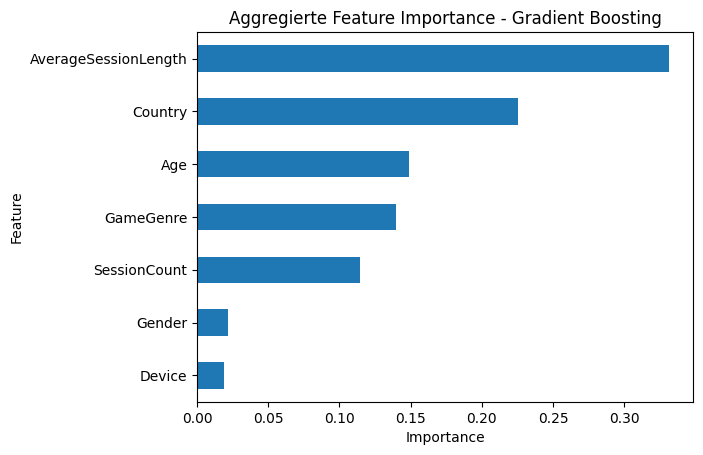

In [16]:
# Diagramm
gb_aggregated_importance.plot(
    kind="barh",
    x="OriginalFeature",
    y="Importance",
    legend=False
)

plt.title("Aggregierte Feature Importance - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

Logistische Regression (Koeffizient)

In [17]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

lr_pipeline.fit(X_train, y_train)

feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = lr_pipeline.named_steps["model"].coef_[0]

lr_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoefficient": abs(coefficients)
}).sort_values(by="AbsCoefficient", ascending=False)

display(lr_coef_df.head(20))

,Feature,Coefficient,AbsCoefficient
22,cat__Country_Netherlands,-0.838795,0.838795
39,cat__GameGenre_Adventure,0.617168,0.617168
9,cat__Country_Bangladesh,0.508456,0.508456
34,cat__Country_None,-0.452595,0.452595
7,cat__Country_Afghanistan,0.448689,0.448689
37,cat__Device_None,0.357349,0.357349
29,cat__Country_Sweden,0.346798,0.346798
23,cat__Country_Norway,0.340233,0.340233
51,cat__GameGenre_Sports,-0.310209,0.310209
8,cat__Country_Australia,-0.305287,0.305287


Aggregierte Regression (Koeffizient)

In [18]:
lr_coef_df["OriginalFeature"] = lr_coef_df["Feature"].apply(extract_original_feature)

lr_aggregated_importance = (
    lr_coef_df
    .groupby("OriginalFeature", as_index=False)["AbsCoefficient"]
    .sum()
    .sort_values(by="AbsCoefficient", ascending=False)
)

display(lr_aggregated_importance)

,OriginalFeature,AbsCoefficient
2,Country,5.685480
4,GameGenre,2.846869
3,Device,0.684759
5,Gender,0.274670
6,SessionCount,0.066558
1,AverageSessionLength,0.052405
0,Age,0.004046


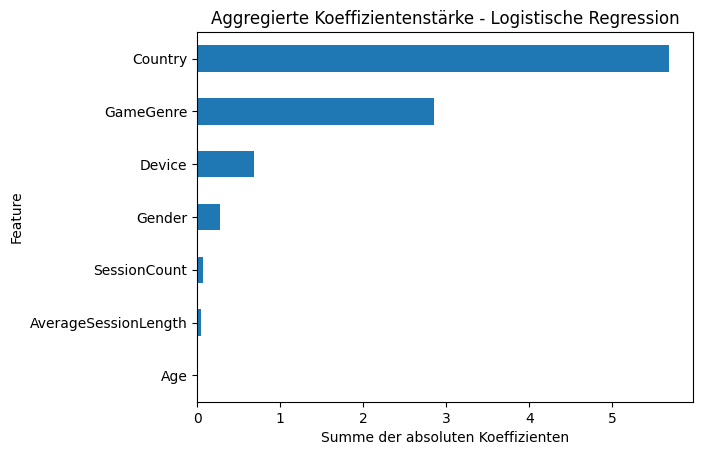

In [19]:
# Diagramm
lr_aggregated_importance.plot(
    kind="barh",
    x="OriginalFeature",
    y="AbsCoefficient",
    legend=False
)

plt.title("Aggregierte Koeffizientenstärke - Logistische Regression")
plt.xlabel("Summe der absoluten Koeffizienten")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

Permutation Importance

In [20]:
from sklearn.inspection import permutation_importance

def get_permutation_importance(pipeline, X_test, y_test, model_name):
    result = permutation_importance(
        pipeline,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42,
        scoring="f1"
    )
    
    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "ImportanceMean": result.importances_mean,
        "ImportanceStd": result.importances_std,
        "Modell": model_name
    }).sort_values(by="ImportanceMean", ascending=False)
    
    return importance_df

lr_perm = get_permutation_importance(lr_pipeline, X_test, y_test, "Logistische Regression")
rf_perm = get_permutation_importance(rf_pipeline, X_test, y_test, "Random Forest")
gb_perm = get_permutation_importance(gb_pipeline, X_test, y_test, "Gradient Boosting")

display(lr_perm)
display(rf_perm)
display(gb_perm)

,Feature,ImportanceMean,ImportanceStd,Modell
1,Gender,0.017765,0.010061,Logistische Regression
3,Device,0.011110,0.010592,Logistische Regression
6,AverageSessionLength,0.007794,0.008913,Logistische Regression
4,GameGenre,0.004975,0.030274,Logistische Regression
2,Country,0.003432,0.019005,Logistische Regression
0,Age,-0.000858,0.000835,Logistische Regression
5,SessionCount,-0.003718,0.008773,Logistische Regression


,Feature,ImportanceMean,ImportanceStd,Modell
2,Country,0.018346,0.006186,Random Forest
6,AverageSessionLength,0.016327,0.008163,Random Forest
1,Gender,0.012368,0.009848,Random Forest
4,GameGenre,0.012327,0.013341,Random Forest
3,Device,0.012266,0.009973,Random Forest
0,Age,0.010266,0.016364,Random Forest
5,SessionCount,0.004142,0.008135,Random Forest


,Feature,ImportanceMean,ImportanceStd,Modell
0,Age,0.000000,0.000000,Gradient Boosting
1,Gender,0.000000,0.000000,Gradient Boosting
3,Device,0.000000,0.000000,Gradient Boosting
5,SessionCount,0.000000,0.000000,Gradient Boosting
6,AverageSessionLength,-0.001961,0.005882,Gradient Boosting
4,GameGenre,-0.001980,0.005941,Gradient Boosting
2,Country,-0.005922,0.009047,Gradient Boosting
